Total Yes: 9
Total No: 5
Probability Yes: 0.6428571428571429
Probability No: 0.35714285714285715
Main Entropy: 0.9402859586706311
Entropy(outlook=sunny): 0.9710 | Yes=2, No=3, Total=5
Entropy(outlook=overcast): 0.0000 | Yes=4, No=0, Total=4
Entropy(outlook=rain): 0.9710 | Yes=3, No=2, Total=5
Information Gain(outlook): 0.2467

Entropy(temp=hot): 1.0000 | Yes=2, No=2, Total=4
Entropy(temp=mild): 0.9183 | Yes=4, No=2, Total=6
Entropy(temp=cool): 0.8113 | Yes=3, No=1, Total=4
Information Gain(temp): 0.0292

Entropy(humidity=high): 0.9852 | Yes=3, No=4, Total=7
Entropy(humidity=normal): 0.5917 | Yes=6, No=1, Total=7
Information Gain(humidity): 0.1518

Entropy(wind=weak): 0.8113 | Yes=6, No=2, Total=8
Entropy(wind=strong): 1.0000 | Yes=3, No=3, Total=6
Information Gain(wind): 0.0481



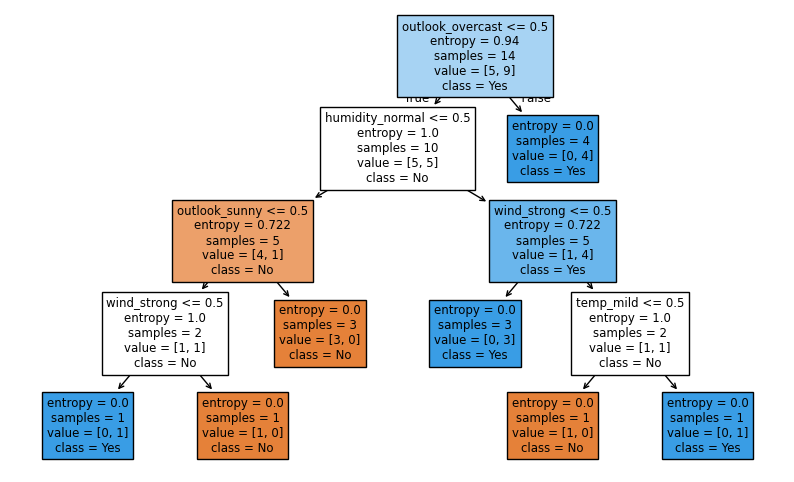

In [7]:
import pandas as pd
import math
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("tennis.csv")

# Add target column manually (Play Tennis: Yes/No)
# Based on the classic dataset, here’s the target:
play = ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
df['play'] = play

# Helper: entropy calculation
def entropy(pos, neg):
    total = pos + neg
    if total == 0: return 0
    p_pos = pos/total if pos else 0
    p_neg = neg/total if neg else 0
    ent = 0
    if p_pos > 0: ent -= p_pos * math.log2(p_pos)
    if p_neg > 0: ent -= p_neg * math.log2(p_neg)
    return ent

# Dataset totals
yes_count = sum(df['play']=='Yes')
no_count = sum(df['play']=='No')
print("Total Yes:", yes_count)
print("Total No:", no_count)
print("Probability Yes:", yes_count/len(df))
print("Probability No:", no_count/len(df))
main_entropy = entropy(yes_count, no_count)
print("Main Entropy:", main_entropy)

# Information Gain calculation
def info_gain(feature):
    values = df[feature].unique()
    weighted_entropy = 0
    for v in values:
        subset = df[df[feature]==v]
        pos = sum(subset['play']=='Yes')
        neg = sum(subset['play']=='No')
        ent = entropy(pos, neg)
        weighted_entropy += (len(subset)/len(df)) * ent
        print(f"Entropy({feature}={v}): {ent:.4f} | Yes={pos}, No={neg}, Total={len(subset)}")
    ig = main_entropy - weighted_entropy
    print(f"Information Gain({feature}): {ig:.4f}\n")
    return ig

# Features to evaluate
features = ['outlook','temp','humidity','wind']
for f in features:
    info_gain(f)

# Encode categorical features
X = pd.get_dummies(df[['outlook','temp','humidity','wind']])
y = df['play']

# Train decision tree using entropy
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

# Plot the tree
plt.figure(figsize=(10,6))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.show()

Class counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
Main Entropy: 1.584962500721156
Entropy(sepal length (cm) in (4.2989999999999995, 5.4]): 0.6496 | counts={'setosa': np.int64(45), 'versicolor': np.int64(6), 'virginica': np.int64(1)}
Entropy(sepal length (cm) in (5.4, 6.3]): 1.2871 | counts={'versicolor': np.int64(33), 'virginica': np.int64(18), 'setosa': np.int64(5)}
Entropy(sepal length (cm) in (6.3, 7.9]): 0.8296 | counts={'virginica': np.int64(31), 'versicolor': np.int64(11), 'setosa': np.int64(0)}
Information Gain(sepal length (cm)): 0.6470

Entropy(sepal width (cm) in (3.2, 4.4]): 0.9503 | counts={'setosa': np.int64(33), 'virginica': np.int64(8), 'versicolor': np.int64(2)}
Entropy(sepal width (cm) in (2.9, 3.2]): 1.5610 | counts={'virginica': np.int64(21), 'setosa': np.int64(15), 'versicolor': np.int64(14)}
Entropy(sepal width (cm) in (1.999, 2.9]): 1.1450 | counts={'versicolor': np.int64(34), 'virginica': np.int64(21), 'setosa': n

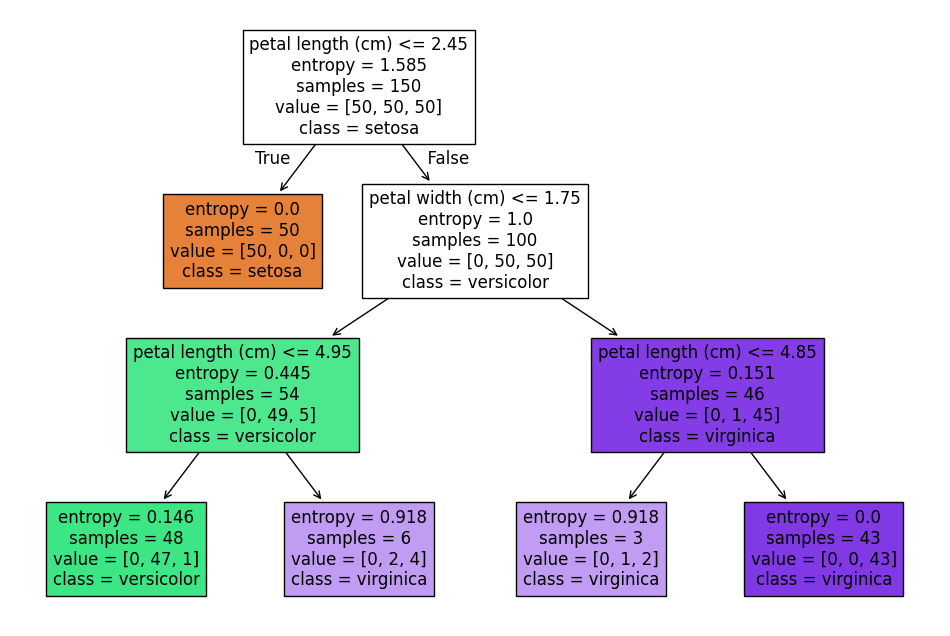

In [9]:
import pandas as pd
import math
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Helper: entropy calculation
def entropy(counts):
    total = sum(counts)
    if total == 0: return 0
    ent = 0
    for c in counts:
        if c > 0:
            p = c/total
            ent -= p * math.log2(p)
    return ent

# Dataset totals
species_counts = df['species'].value_counts()
print("Class counts:\n", species_counts)
main_entropy = entropy(species_counts.values)
print("Main Entropy:", main_entropy)

# Information Gain calculation
def info_gain(feature):
    values = pd.qcut(df[feature], q=3, duplicates='drop')  # discretize continuous features
    weighted_entropy = 0
    for v in values.unique():
        subset = df[values==v]
        counts = subset['species'].value_counts()
        ent = entropy(counts.values)
        weighted_entropy += (len(subset)/len(df)) * ent
        print(f"Entropy({feature} in {v}): {ent:.4f} | counts={dict(counts)}")
    ig = main_entropy - weighted_entropy
    print(f"Information Gain({feature}): {ig:.4f}\n")
    return ig

# Features to evaluate
for f in iris.feature_names:
    info_gain(f)

# Train decision tree using entropy
X = df[iris.feature_names]
y = df['species']
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)  # limit depth for clarity
clf.fit(X, y)

# Plot the tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=clf.classes_, filled=True)
plt.show()
